In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import joblib
import pandas as pd
import shap
import numpy as np

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

### Logistic regression

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8419


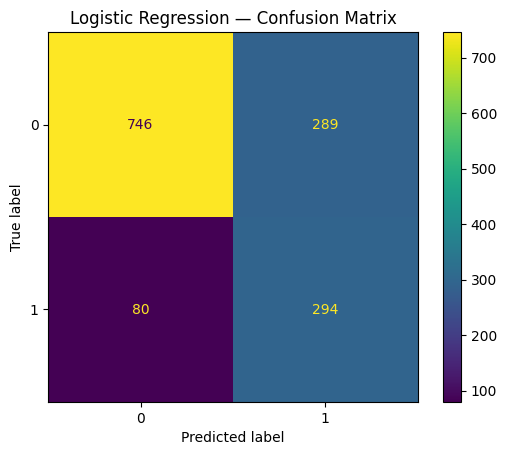

In [3]:
# Train
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

- High false positive due to class_weight='balanced', the model is agressive about spotting churn
- AUC score is more reliable due to an imbalanced data set
- Overall a solid baseline model

### Random Forest

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC: 0.8206


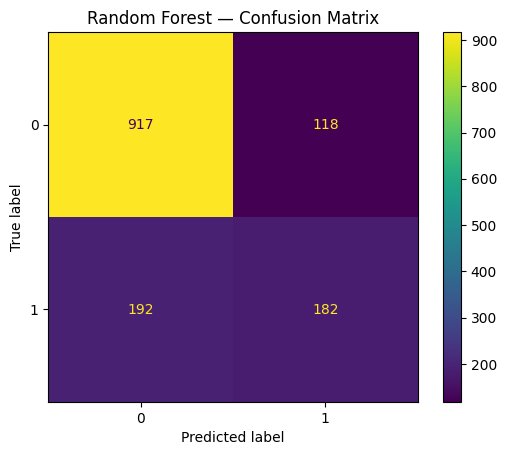

In [4]:
# Train
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # uses all CPU cores to train faster
)
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title('Random Forest — Confusion Matrix')
plt.show()

Logistic Regression with class_weight='balanced' aggressively overcompensates for the 27/73 imbalance, it lowers its decision threshold, casting a wide net to catch churners. It would rather flag 10 false alarms than miss one real churner. High recall, messy precision.

Random Forest with class_weight='balanced' handles imbalance differently. Each tree votes independently, and the majority vote naturally skews conservative, the forest needs reasonable consensus across trees before predicting churn. Stricter, fewer false alarms, but misses more real churners.

### XGBoost

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1035
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.76      0.77      1409

ROC-AUC: 0.8197


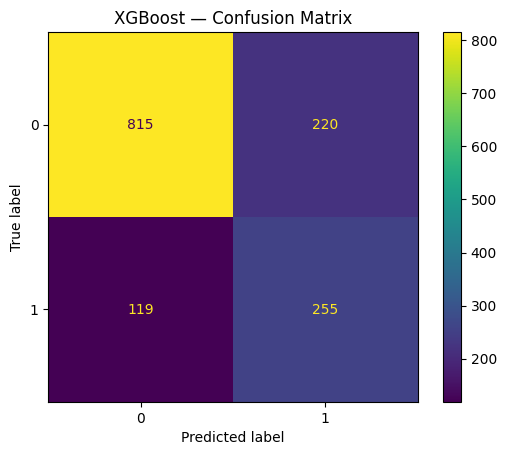

In [5]:

# Train
xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Classification report
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title('XGBoost — Confusion Matrix')
plt.show()

The Initial Model actually performs worse than Random Forest and Logistic Regression in terms of the ROC-AUC score
We will tweak hyper parameter using a GridSearchCV 

Starting Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- Grid Search Results ---
Best ROC-AUC Score: 0.8470
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.8451


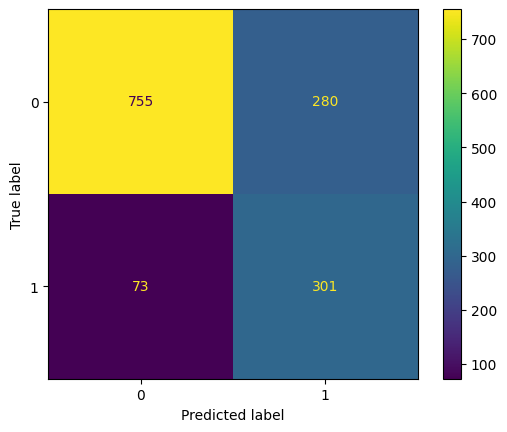

In [6]:
# Define the Grid 
param_grid = {
    'max_depth': [3, 4, 5],             # How deep the trees can grow
    'learning_rate': [0.01, 0.05, 0.1], # How fast the model learns
    'n_estimators': [100, 300]          # How many trees to build
}


# Base Model
xgb_base = XGBClassifier(
    random_state=42,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss'
)

# Configure GridSearchCV with AUC as the score not Accuracy to assess the model
grid_search = GridSearchCV(
    estimator=xgb_base, 
    param_grid=param_grid, 
    scoring='roc_auc', 
    cv=5, 
    verbose=1,      # Prints progress updates
    n_jobs=-1       # Uses all the computer's cores to speed it up
)

# Search
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

# The Reveal
print("\n--- Grid Search Results ---")
print(f"Best ROC-AUC Score: {grid_search.best_score_:.4f}") # This is compared with the cross validation data
print("Best Parameters:", grid_search.best_params_)

# Use the Best Model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]


# Visualizing Metrics
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.plot('Tweaked XGBoost-Confusion Matrix')
plt.show()


## Model comparison & conclusion

Tuned XGBoost achieves the best overall performance, narrowly outperforming 
Logistic Regression on ROC-AUC (0.84 vs 0.84) while improving churn F1 
from 0.61 to 0.63 and recall from 0.79 to 0.80.

Comparing the two XGBoost models highlights a classic precision-recall tradeoff — 
the default model is more conservative (higher precision, lower recall) while the 
tuned model, optimised for AUC via GridSearch, casts a wider net to catch more 
churners at the cost of more false alarms.

For a churn use case, recall is the more business-critical metric — missing a 
churner is more costly than a false retention offer — which makes the tuned 
XGBoost the preferred model.

Best hyperparameters found: learning_rate=0.05, max_depth=3, n_estimators=100.

---
### SHAP Analysis on the XGBoost Model

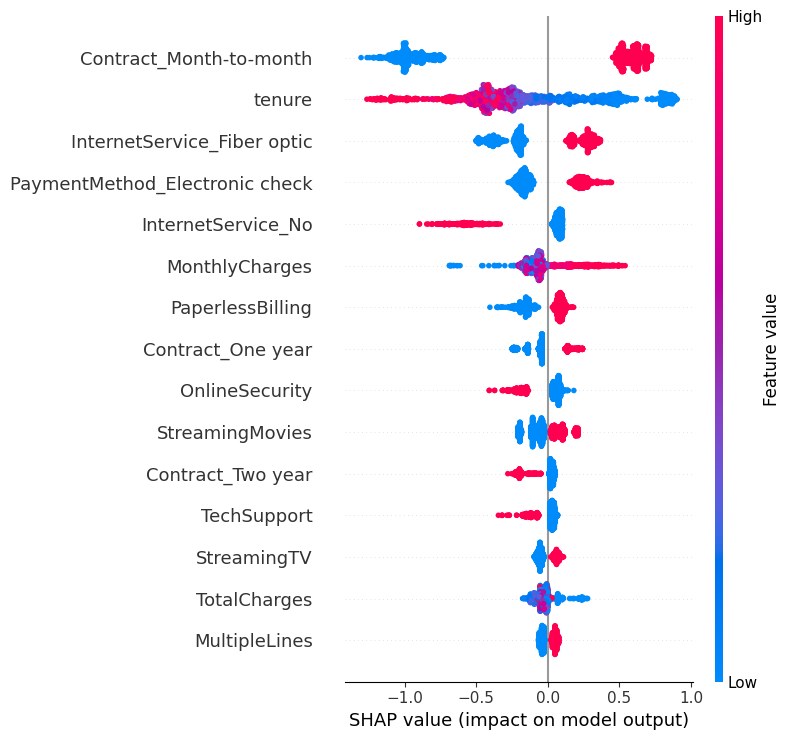

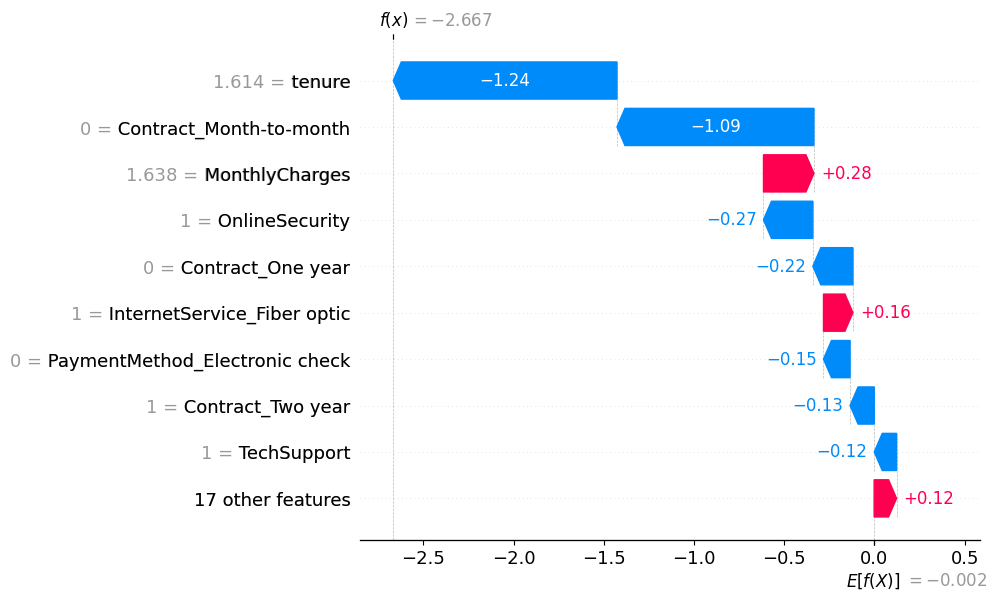

In [7]:
# Build explainer on the tweaked model
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer(X_test)

# Plot 1 — Global feature importance
shap.summary_plot(shap_values, X_test, max_display=15)

# Plot 2 — Single customer waterfall (first customer in test set)
shap.plots.waterfall(shap_values[0])

The Month-to-Month Trap: Looking at the top row. The big clump of Red dots is far to the right. This means when Contract_Month-to-month is High ("Yes"), it massively increases churn probability.

The Loyalty Shield:  The Red dots (high tenure) are stretched far to the left. This proves mathematically that the longer a customer stays, the less likely they are to churn. Conversely, the Blue dots (low tenure) are on the right, meaning new customers are a high flight risk.

Fiber Optic Issues: On the third row, having Fiber Optic (Red) pushes the model toward churn. This suggests there might be a price or reliability issue with the Fiber Optic service. Further investigation needed.

---

#### Waterfall plot of 5 churned customers

Generating SHAP plots for 5 predicted churners...

--- Customer Array Index: 1 | Original Data Index: 1 ---


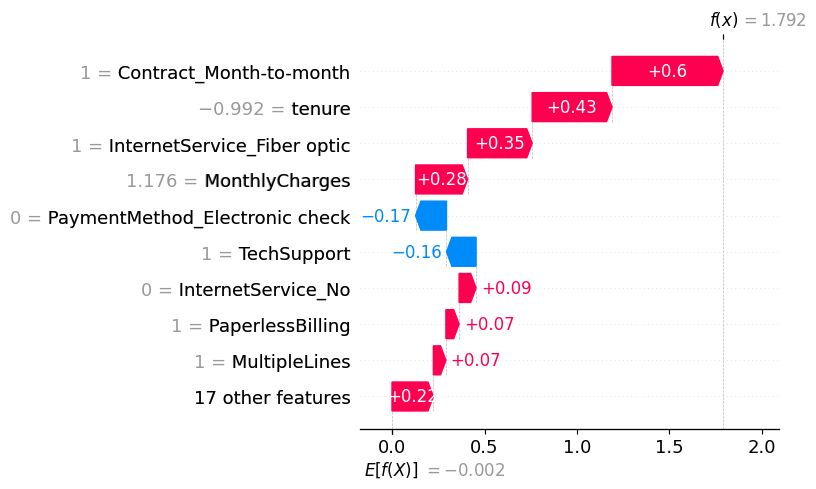


--- Customer Array Index: 3 | Original Data Index: 3 ---


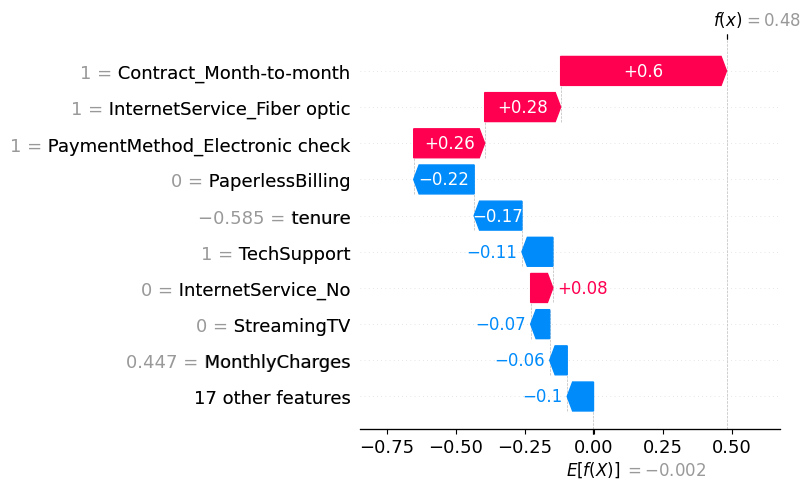


--- Customer Array Index: 5 | Original Data Index: 5 ---


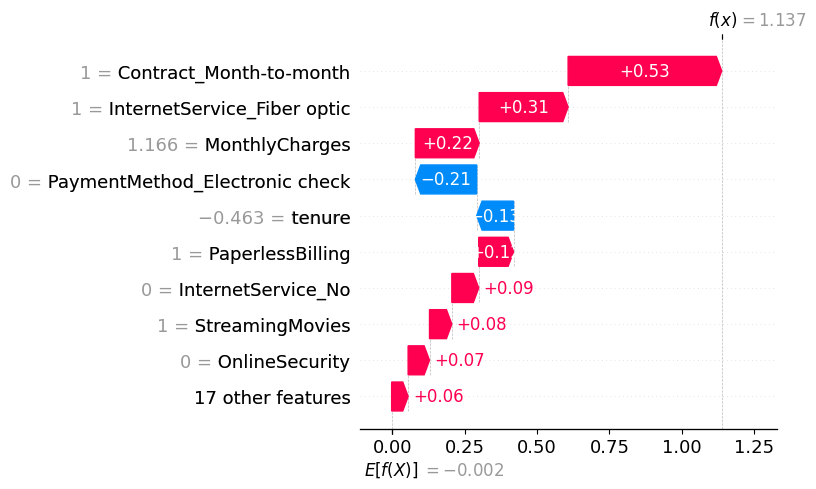


--- Customer Array Index: 6 | Original Data Index: 6 ---


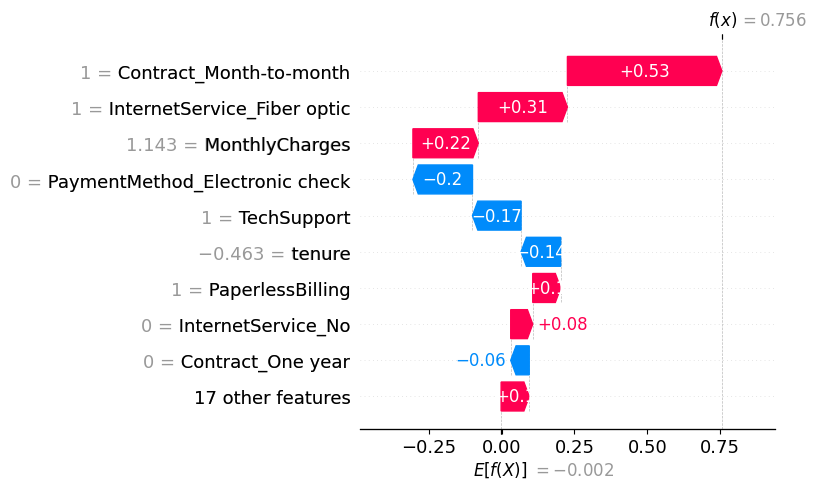


--- Customer Array Index: 9 | Original Data Index: 9 ---


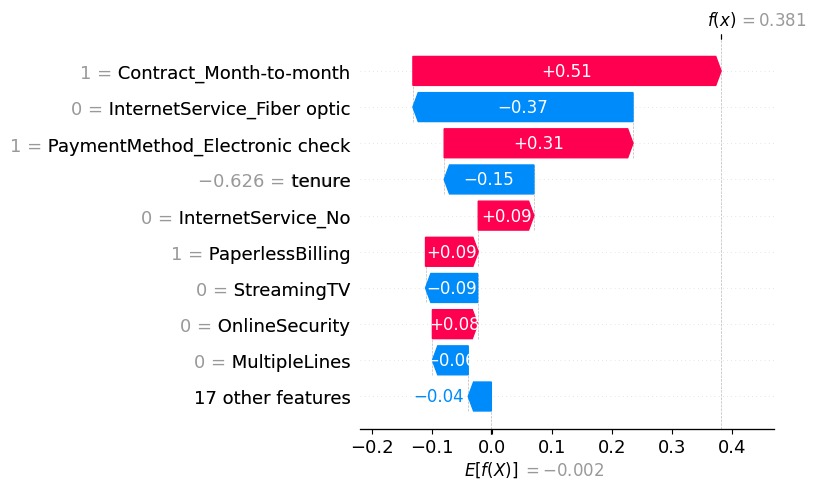

In [8]:
# Create a mask (a list of True/False) for customers predicted to churn
predicted_churners_mask = (y_pred_best == 1)

# Convert that mask into actual row numbers (0, 1, 2, 3...) np.where finds the exact array positions where the mask is True
churner_row_numbers = np.where(predicted_churners_mask)[0]

# Loop through the first 5 of those row numbers
print("Generating SHAP plots for 5 predicted churners...")

for i in churner_row_numbers[:5]:
    
    # Get customer
    actual_customer_id = X_test.index[i]
    print(f"\n--- Customer Array Index: {i} | Original Data Index: {actual_customer_id} ---")
    
    # Generate the plot
    shap.plots.waterfall(shap_values[i], show=False)

    # Adjusting the size
    plt.gcf().set_size_inches(8, 5) 
    plt.tight_layout()

    # Display the plot cleanly before moving to the next one in the loop
    plt.show()

Individual waterfall analysis of predicted churners validates the global insights from our SHAP summary plot. Across the sampled profiles, Month-to-month contracts, Electronic Check payment methods, and Fiber Optic internet service consistently act as the primary positive drivers pushing individuals toward a high churn probability. This confirms that these three factors consistently act as the primary drivers pushing individual predictions toward high churn probability, confirming these features carry strong predictive weight both globally and at the individual level

In [10]:
# Saving the model for streamlit
joblib.dump(best_xgb, '../models/best_xgb.pkl')

print("Models saved.")

Models saved.
